# Data Analysis

In [2]:
library(dplyr)
library(car)
library(ggplot2)
library(rmarkdown)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




In [3]:
dataset_url <- "https://raw.githubusercontent.com/wilkmzhou/STAT306_PROJECT_REPORT_2026/refs/heads/main/mercedes_benz_listings_cleaned.csv" # load dataset from github

benzDataRaw <- read.csv(dataset_url)                                                                                                        # read dataset
head(benzDataRaw, n = 3)

,Vehicle_Name,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<dbl>
1,2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
2,2025 Mercedes-Benz GLE 580 4MATIC,2025,1,GLE,E 580,SUV,0,1,3154,Low (< 20K),82975,Luxury (> $70K),26.307863
3,2025 Mercedes-Benz GLS 450 4MATIC,2025,1,GLS,S 450,SUV,0,1,15496,Low (< 20K),75500,Luxury (> $70K),4.872225


In [4]:
benzData <- benzDataRaw |> 
    na.omit() |>                                                                                              # remove any NA rows 
    select(-Price_Per_Mile, -Price_Category, -Year, -Mileage_Category, -Vehicle_Name, -Model_Series, -Is_AMG) |> # remove redundant variables
    select(-Trim_Level, -Is_4MATIC)                                                                           # remove uninterested variables
head(benzData, n = 3)

,Vehicle_Age,Body_Type,Mileage_Miles,Price_USD
,<int>,<chr>,<int>,<int>
1,1,Other,9860,151900
2,1,SUV,3154,82975
3,1,SUV,15496,75500


# Exploratory Data Analysis
## Numerical Variables
### Correlation Plot

,Vehicle_Age,Mileage_Miles,Price_USD
Vehicle_Age,1.0000000,0.7895362,-0.5172287
Mileage_Miles,0.7895362,1.0000000,-0.5478500
Price_USD,-0.5172287,-0.5478500,1.0000000


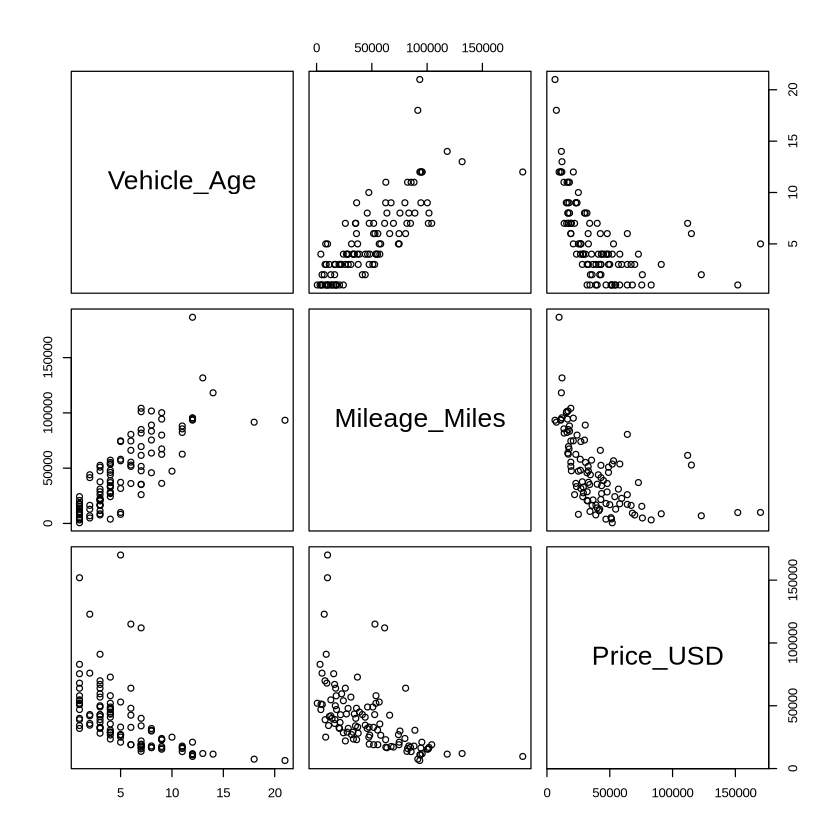

In [5]:
benzDataInt <- benzData |>
    select(-Body_Type) # filter dataset from categorical variables

pairs(benzDataInt) # scatterplot between each pair of numerical variables
cor(benzDataInt) # correlation between each pair of numerical variables

,log_Vehicle_Age,log_Mileage_Miles,log_Price_USD
log_Vehicle_Age,1.0000000,0.7744447,-0.6830181
log_Mileage_Miles,0.7744447,1.0000000,-0.6459359
log_Price_USD,-0.6830181,-0.6459359,1.0000000


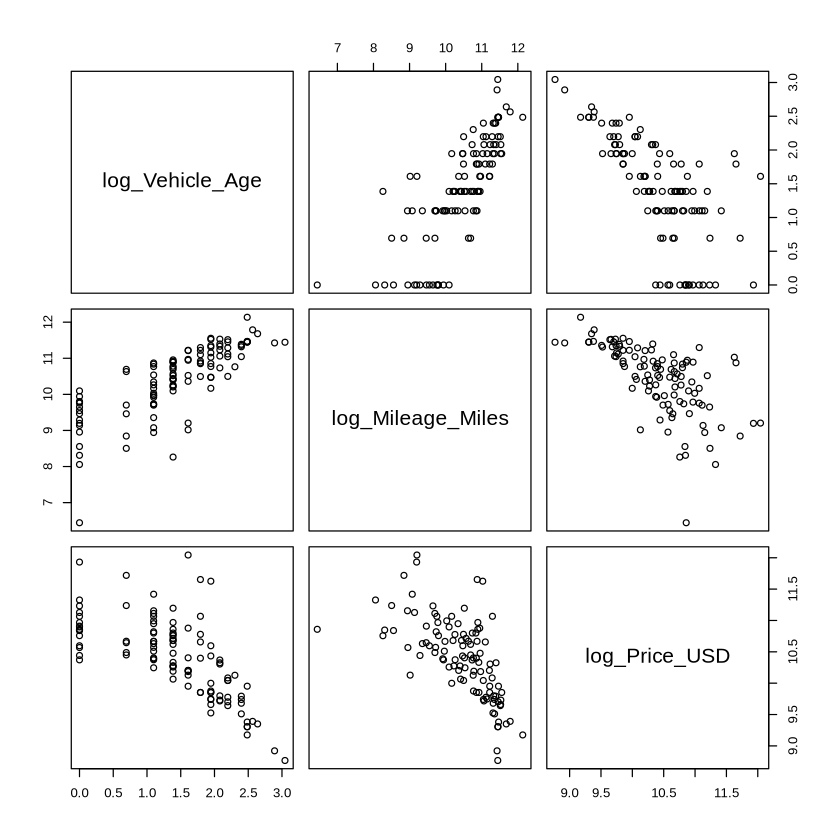

In [6]:
benzDataTransf <- benzDataInt |>
    transmute(log_Vehicle_Age = log(Vehicle_Age), log_Mileage_Miles = log(Mileage_Miles), log_Price_USD = log(Price_USD)) # transform variables 

pairs(benzDataTransf)                                                                                                     # find correlation between variables
cor(benzDataTransf)

### Categorical Variables

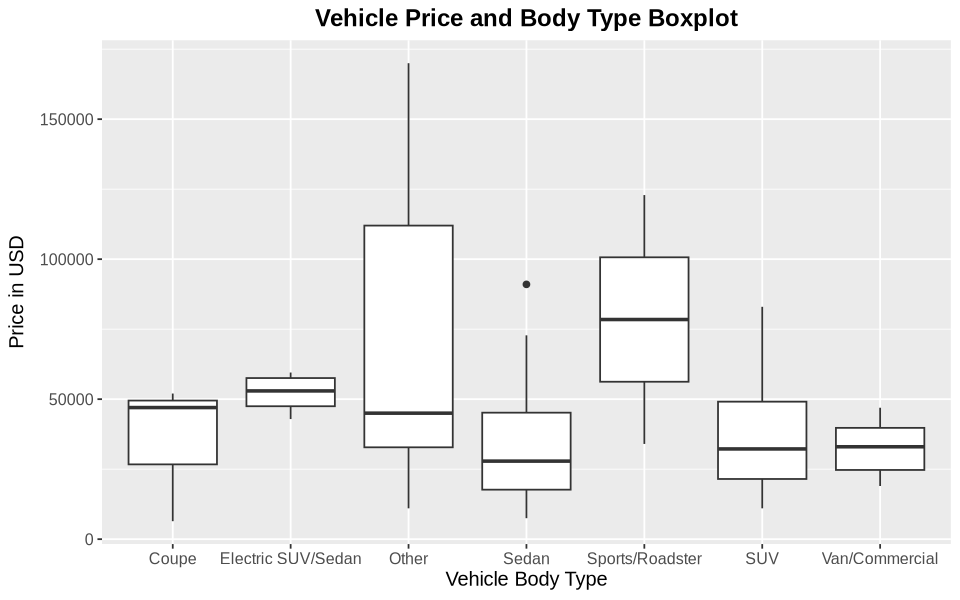

In [7]:
options(repr.plot.width = 8, repr.plot.height = 5)
benzDataCat <- benzData |>
    select(-Vehicle_Age, -Mileage_Miles) # filter dataset from numerical variables

benzBodyBoxplot <- benzDataCat |>
    ggplot(aes(x = Body_Type, y = Price_USD)) + 
    geom_boxplot() + 
    ylab("Price in USD") + # y-axis label change 
    xlab("Vehicle Body Type") + # x-axis label change
    ggtitle("Vehicle Price and Body Type Boxplot") + # title
    theme(plot.title = element_text(hjust = 0.5, face = "bold"), text = element_text(size = 12)) # title alignment and text size increase

benzBodyBoxplot

### Fitting Linear Regression Model 1 (no variable transforming)

In [8]:
benzFit1 <- lm(Price_USD ~ ., data = benzData) # fit linear regression model with all variables in filtered dataset

summary(benzFit1) # print linear regression fit statistics


Call:
lm(formula = Price_USD ~ ., data = benzData)

Residuals:
   Min     1Q Median     3Q    Max 
-39754 -12028  -2008   6347  89793 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 60773.9663 12847.5036   4.730 7.45e-06 ***
Vehicle_Age                 -1931.5925   899.7466  -2.147  0.03425 *  
Body_TypeElectric SUV/Sedan  6239.2677 16334.5738   0.382  0.70330    
Body_TypeOther              31967.1271 13648.1126   2.342  0.02117 *  
Body_TypeSedan               1901.8133 12884.7487   0.148  0.88296    
Body_TypeSports/Roadster    32461.9154 19089.6691   1.700  0.09218 .  
Body_TypeSUV                -2769.8937 12782.1267  -0.217  0.82889    
Body_TypeVan/Commercial     -1683.1499 15017.4523  -0.112  0.91099    
Mileage_Miles                  -0.2899     0.1002  -2.894  0.00468 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 20810 on 99 degrees of freedom
Multiple R-squa

### Check Linear Regression VIF

In [9]:
vifBenz <- vif(benzFit1)
vifBenz

,GVIF,Df,GVIF^(1/(2*Df))
Vehicle_Age,2.912700,1,1.706663
Body_Type,1.155886,6,1.012145
Mileage_Miles,2.837534,1,1.684498


### Residuals and Fitted Values Scatterplot

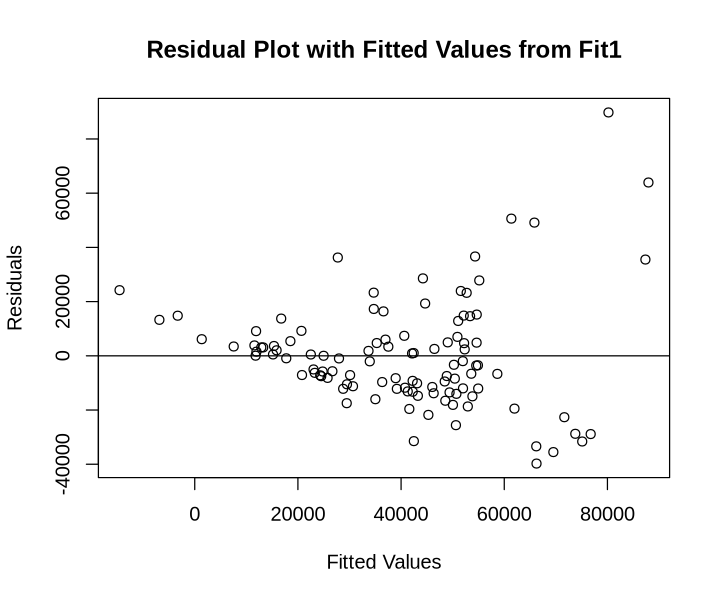

In [10]:
options(repr.plot.width = 6, repr.plot.height = 5)
plot(fitted(benzFit1), resid(benzFit1), main = "Residual Plot with Fitted Values from Fit1", xlab = "Fitted Values", ylab = "Residuals") # plot fitted values and residuals
abline(0,0)                                                                                                                              # add horizontal line at 0 


### Another Fitted Model to Address Heteroscedasticity

In [11]:
benzFit2 <- lm(log(Price_USD) ~ log(Vehicle_Age) + log(Mileage_Miles) + Body_Type, data = benzData) # fit linear regression with transformed variables

summary(benzFit2)


Call:
lm(formula = log(Price_USD) ~ log(Vehicle_Age) + log(Mileage_Miles) + 
    Body_Type, data = benzData)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.96005 -0.21053 -0.06618  0.19218  1.05388 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 12.46534    0.59220  21.049  < 2e-16 ***
log(Vehicle_Age)            -0.40816    0.08215  -4.969 2.82e-06 ***
log(Mileage_Miles)          -0.20837    0.06604  -3.155  0.00213 ** 
Body_TypeElectric SUV/Sedan  0.98098    0.30717   3.194  0.00188 ** 
Body_TypeOther               1.19907    0.25949   4.621 1.15e-05 ***
Body_TypeSedan               0.70603    0.24585   2.872  0.00499 ** 
Body_TypeSports/Roadster     1.16187    0.35918   3.235  0.00166 ** 
Body_TypeSUV                 0.55474    0.24153   2.297  0.02374 *  
Body_TypeVan/Commercial      0.74231    0.28224   2.630  0.00990 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual stan

### New Residuals and Fitted Values Scatterplot 

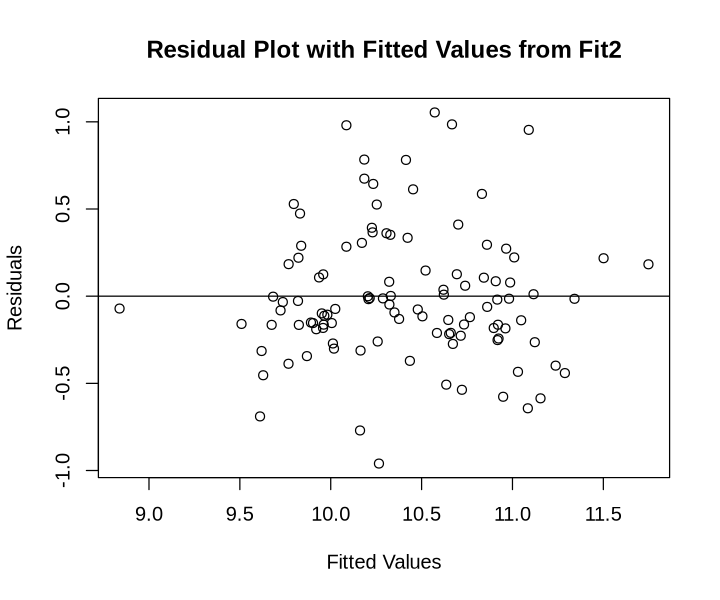

In [12]:
plot(fitted(benzFit2), resid(benzFit2), main = "Residual Plot with Fitted Values from Fit2", xlab = "Fitted Values", ylab = "Residuals") # plot fitted values and residuals
abline(0,0)  

In [13]:
vifBenzFit2 <- vif(benzFit2) # compute vif of fit with transformed variables

vifBenzFit2 

,GVIF,Df,GVIF^(1/(2*Df))
log(Vehicle_Age),2.866540,1,1.693086
log(Mileage_Miles),2.792435,1,1.671058
Body_Type,1.255463,6,1.019140


### QQ Plot

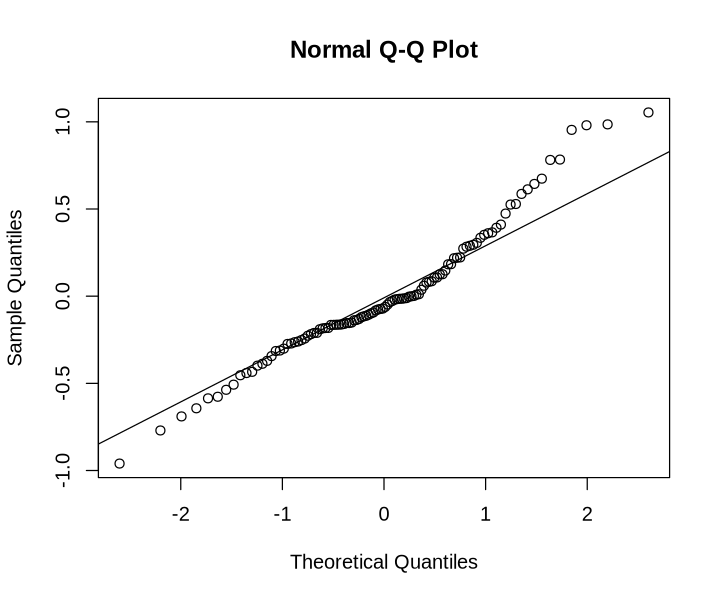

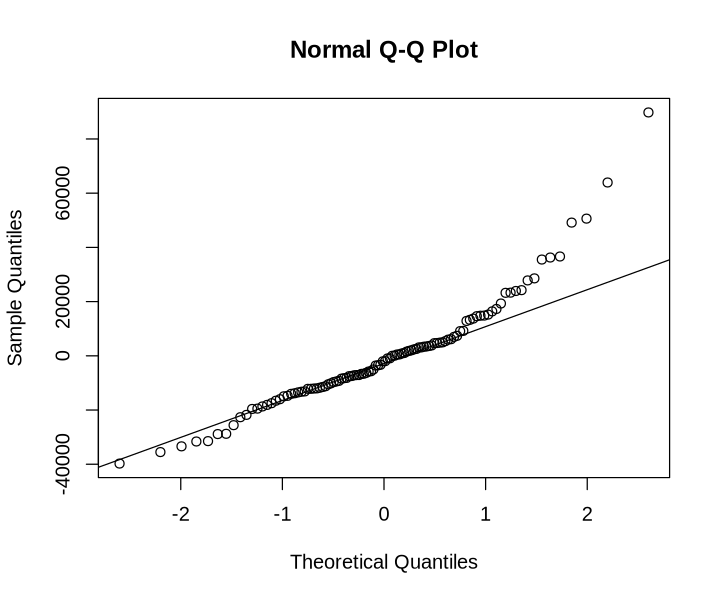

In [14]:
resFit1 <- resid(benzFit1)
resFit2 <- resid(benzFit2)

qqnorm(resFit2) # display QQ plot of linear regression with transformed variables 
qqline(resFit2)

qqnorm(resFit1) # display QQ plot of linear regression with no transformed variables
qqline(resFit1)

In [15]:
rmarkdown::convert_ipynb("Stage2ProjectReport.ipynb") 

In [16]:
knitr::purl("Stage2ProjectReport.Rmd")



processing file: Stage2ProjectReport.Rmd



1/31                   
2/31 [unnamed-chunk-1] 
3/31                   
4/31 [unnamed-chunk-2] 
5/31                   
6/31 [unnamed-chunk-3] 
7/31                   
8/31 [unnamed-chunk-4] 
9/31                   
10/31 [unnamed-chunk-5] 
11/31                   
12/31 [unnamed-chunk-6] 
13/31                   
14/31 [unnamed-chunk-7] 
15/31                   
16/31 [unnamed-chunk-8] 
17/31                   
18/31 [unnamed-chunk-9] 
19/31                   
20/31 [unnamed-chunk-10]
21/31                   
22/31 [unnamed-chunk-11]
23/31                   
24/31 [unnamed-chunk-12]
25/31                   
26/31 [unnamed-chunk-13]
27/31                   
28/31 [unnamed-chunk-14]
29/31                   
30/31 [unnamed-chunk-15]
31/31                   


output file: Stage2ProjectReport.R




[1] "Stage2ProjectReport.R"